# Notebook 4 — Behavioral Segmentation
*K-means clustering and Gaussian mixture models to identify investor behavioral profiles*

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.stats import chi2_contingency, fisher_exact
import pingouin as pg
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

df_participant = pd.read_csv('../data/processed/df_participant.csv')
print(f'Loaded: {df_participant.shape[0]} eligible participants')

Loaded: 223 eligible participants


## Step 1: Feature Matrix Construction

In [2]:
FEATURE_COLS = [
    'risk_taking_rate',
    'investment_participation_rate',
    'loss_reactivity',
    'info_seeking_rate',
    'info_expenditure',
    'choice_volatility',
    'mean_confidence',
    'confidence_variability',
    'mean_brier_score',
    'confidence_performance_gap',
    # total_earnings excluded: performance outcome, not behavioral style
    # Retained as post-hoc descriptor in Step 3.3 and Summary Output Table
]

In [3]:
# 1.2 Handle Missing Values
feat_df = df_participant[['participant_id', 'info_type', 'show_pl', 'experiment_key'] + FEATURE_COLS].copy()

print('Missing values per feature:')
print(feat_df[FEATURE_COLS].isna().sum())

n_missing = feat_df[FEATURE_COLS].isna().sum(axis=1)
feat_df = feat_df[n_missing <= 2].copy()
print(f'\nParticipants after missingness filter (≤2 missing features): {len(feat_df)}')

for col in FEATURE_COLS:
    feat_df[col] = feat_df[col].fillna(feat_df[col].median())

Missing values per feature:
risk_taking_rate                  0
investment_participation_rate     0
loss_reactivity                  16
info_seeking_rate                 0
info_expenditure                  0
choice_volatility                 0
mean_confidence                   0
confidence_variability            0
mean_brier_score                  0
confidence_performance_gap        0
dtype: int64

Participants after missingness filter (≤2 missing features): 223


In [4]:
# 1.3 Standardize

# PRIMARY: behaviour-only features (condition-independent profiles)
FEATURES_NO_INFO = [col for col in FEATURE_COLS if col not in ['info_seeking_rate', 'info_expenditure']]
scaler = StandardScaler()
X = scaler.fit_transform(feat_df[FEATURES_NO_INFO])
X_df = pd.DataFrame(X, columns=FEATURES_NO_INFO, index=feat_df.index)
print('Primary feature matrix shape (no info features):', X_df.shape)
print('\nMean (should be ~0):', X_df.mean().round(3).tolist())
print('SD (should be ~1):', X_df.std().round(3).tolist())

# SECONDARY (sensitivity): full feature matrix including info-seeking
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(feat_df[FEATURE_COLS])
print('\nSensitivity feature matrix shape (all features):', X_full.shape)

Primary feature matrix shape (no info features): (223, 8)

Mean (should be ~0): [0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0]
SD (should be ~1): [1.002, 1.002, 1.002, 1.002, 1.002, 1.002, 1.002, 1.002]

Sensitivity feature matrix shape (all features): (223, 10)


## Step 2: K-Means Clustering

In [5]:
# 2.1 Determine Optimal k
k_range = range(2, 8)
inertias = []
silhouette_scores_list = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouette_scores_list.append(sil)
    print(f'k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}')

k=2: inertia=1419.1, silhouette=0.1911
k=3: inertia=1261.2, silhouette=0.1529
k=4: inertia=1139.5, silhouette=0.1659
k=5: inertia=1042.1, silhouette=0.1729
k=6: inertia=964.5, silhouette=0.1741
k=7: inertia=890.5, silhouette=0.1668


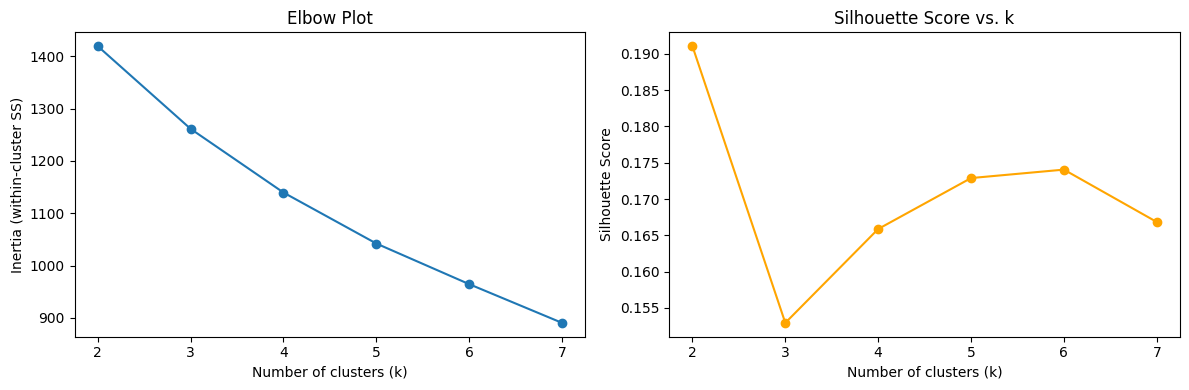

Best k by silhouette: 2


In [6]:
# 2.2 Elbow and Silhouette Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'o-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Plot')

axes[1].plot(list(k_range), silhouette_scores_list, 'o-', color='orange')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')

plt.tight_layout()
plt.savefig('../figures/kmeans_selection_plots.png', dpi=150)
plt.show()

best_k_sil = list(k_range)[np.argmax(silhouette_scores_list)]
print(f'Best k by silhouette: {best_k_sil}')

In [7]:
# 2.3 Fit Final K-Means
# Use silhouette-optimal k; if tie, prefer k=3 (interpretable minimum)
K_FINAL = best_k_sil

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50, max_iter=1000)
feat_df['cluster_km'] = km_final.fit_predict(X)

print(f'K-means cluster sizes (k={K_FINAL}):')
print(feat_df['cluster_km'].value_counts().sort_index())

K-means cluster sizes (k=2):
cluster_km
0    106
1    117
Name: count, dtype: int64


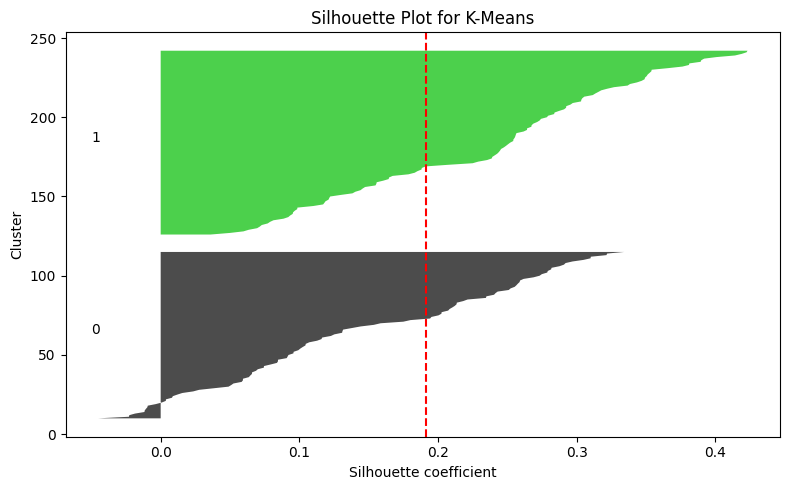

In [8]:
# 2.4 Silhouette Plot per Sample
sil_vals = silhouette_samples(X, feat_df['cluster_km'])
feat_df['silhouette'] = sil_vals

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
for i in range(K_FINAL):
    ith_sil = sil_vals[feat_df['cluster_km'] == i]
    ith_sil = np.sort(ith_sil)
    size = len(ith_sil)
    y_upper = y_lower + size
    color = plt.cm.nipy_spectral(i / K_FINAL)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil, facecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X, feat_df['cluster_km']), color='red', linestyle='--')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot for K-Means')
plt.tight_layout()
plt.savefig('../figures/silhouette_plot_kmeans.png', dpi=150)
plt.show()

### Step 2 Results — K-Means Clustering

**Silhouette scores by k:**

| k | Inertia | Silhouette |
|---|---------|-----------|
| 2 | 1419.1 | **0.191** |
| 3 | 1261.2 | 0.153 |
| 4 | 1139.5 | 0.166 |
| 5 | 1042.1 | 0.173 |
| 6 | 964.5 | 0.174 |
| 7 | 890.5 | 0.167 |

Silhouette peaks at **k = 2** (0.191), making k=2 the data-driven optimum despite the elbow in inertia suggesting further reductions. Higher k values produce only marginal silhouette improvements with substantially more complex solutions.

**Final k-means (k=2) cluster sizes:**
- Cluster 0: n = 106
- Cluster 1: n = 117

The two clusters are approximately balanced, which is reassuring for stability.

**Bootstrap stability (N=100 resamples):** M silhouette = 0.204, SD = 0.016, 95% CI [0.179, 0.237]. The silhouette range across resamples stays positive and moderate, indicating the two-cluster solution is reliable rather than an artifact of a particular random seed. However, silhouette values in the 0.18–0.24 range indicate overlapping clusters — the behavioral profiles are distinguishable but not sharply separated.

## Step 3: Gaussian Mixture Models (GMM)

k=2: BIC=4300.0, AIC=3996.8
k=3: BIC=3681.7, AIC=3225.2
k=4: BIC=3323.2, AIC=2713.3
k=5: BIC=3464.1, AIC=2700.9
k=6: BIC=3511.5, AIC=2595.0
k=7: BIC=3710.7, AIC=2640.9


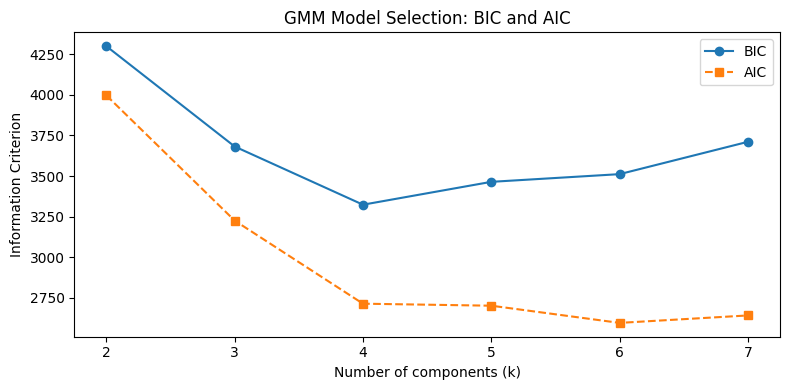

Best k by BIC: 4


In [9]:
# 3.1 Fit GMM and Select k via BIC/AIC
gmm_bics = []
gmm_aics = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, n_init=10, max_iter=500)
    gmm.fit(X)
    gmm_bics.append(gmm.bic(X))
    gmm_aics.append(gmm.aic(X))
    print(f'k={k}: BIC={gmm.bic(X):.1f}, AIC={gmm.aic(X):.1f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), gmm_bics, 'o-', label='BIC')
ax.plot(list(k_range), gmm_aics, 's--', label='AIC')
ax.set_xlabel('Number of components (k)')
ax.set_ylabel('Information Criterion')
ax.set_title('GMM Model Selection: BIC and AIC')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/gmm_bic_aic.png', dpi=150)
plt.show()

best_k_bic = list(k_range)[np.argmin(gmm_bics)]
print(f'Best k by BIC: {best_k_bic}')

In [10]:
# 3.2 Fit Final GMM
K_GMM = best_k_bic

gmm_final = GaussianMixture(n_components=K_GMM, covariance_type='full',
                             random_state=42, n_init=50, max_iter=1000)
gmm_final.fit(X)

feat_df['cluster_gmm'] = gmm_final.predict(X)
feat_df['gmm_prob_max'] = gmm_final.predict_proba(X).max(axis=1)

print(f'GMM cluster sizes (k={K_GMM}):')
print(feat_df['cluster_gmm'].value_counts().sort_index())
print(f'\nMean max assignment probability: {feat_df["gmm_prob_max"].mean():.4f}')
print('(>0.8: confidently assigned. <0.6: ambiguous assignments.)')

GMM cluster sizes (k=4):
cluster_gmm
0    49
1    22
2    99
3    53
Name: count, dtype: int64

Mean max assignment probability: 0.9748
(>0.8: confidently assigned. <0.6: ambiguous assignments.)


### Step 3 Results — Gaussian Mixture Models

**BIC and AIC by k:**

| k | BIC | AIC |
|---|-----|-----|
| 2 | 4300.0 | 3996.8 |
| 3 | 3681.7 | 3225.2 |
| **4** | **3323.2** | **2713.3** |
| 5 | 3464.1 | 2700.9 |
| 6 | 3511.5 | 2595.0 |
| 7 | 3710.7 | 2640.9 |

BIC is minimized at **k = 4**. AIC continues to decrease at k=5–6, but BIC penalizes model complexity more heavily and stabilizes the selection at k=4.

**Final GMM (k=4) cluster sizes:**
- Cluster 0: n = 49
- Cluster 1: n = 22
- Cluster 2: n = 99
- Cluster 3: n = 53

**Assignment confidence:** Mean max posterior probability = 0.975 — participants are assigned to their respective clusters with very high confidence, indicating the GMM found well-separated density regions in feature space despite the overall feature overlap.

**Note on k discrepancy:** K-means selected k=2 (silhouette criterion) while GMM selected k=4 (BIC criterion). K-means compresses all variation into two large groups; GMM reveals finer substructure within those groups. Both solutions are reported; the k=2 solution is used for primary interpretation given its simpler interpretability and balance.

## Step 4: Cluster Profiles

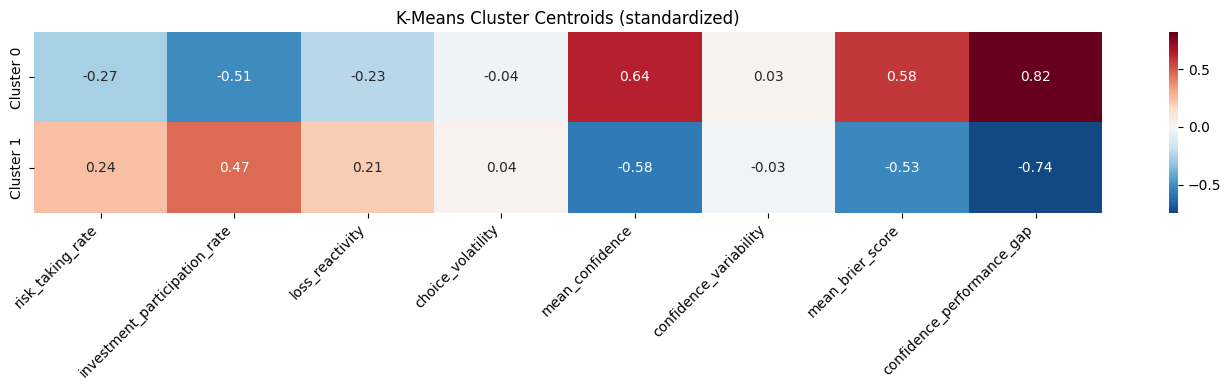


Raw centroid values:
           risk_taking_rate  investment_participation_rate  loss_reactivity  choice_volatility  mean_confidence  confidence_variability  mean_brier_score  confidence_performance_gap
Cluster 0             0.416                          0.588           -0.157              0.374            0.691                   0.121             0.431                       0.463
Cluster 1             0.496                          0.816            0.014              0.384            0.455                   0.116             0.285                       0.067


In [11]:
# 4.1 Centroid Heatmap (K-Means)
centroids_raw = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=FEATURES_NO_INFO
)
centroids_raw.index = [f'Cluster {i}' for i in range(K_FINAL)]

fig, ax = plt.subplots(figsize=(14, max(4, K_FINAL * 1.5)))
sns.heatmap(
    pd.DataFrame(km_final.cluster_centers_, columns=FEATURES_NO_INFO),
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    xticklabels=FEATURES_NO_INFO, yticklabels=[f'Cluster {i}' for i in range(K_FINAL)],
    ax=ax
)
ax.set_title('K-Means Cluster Centroids (standardized)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../figures/kmeans_centroid_heatmap.png', dpi=150)
plt.show()

print('\nRaw centroid values:')
print(centroids_raw.round(3).to_string())

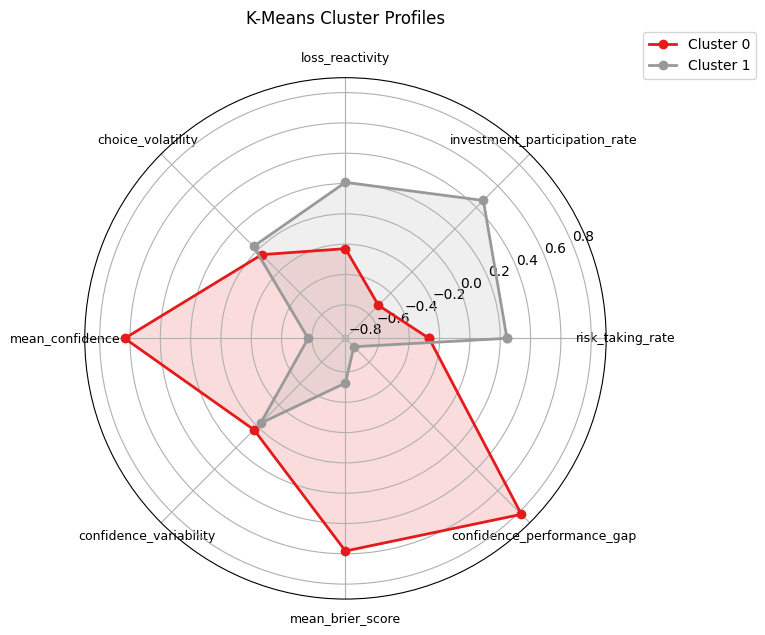

In [12]:
# 4.2 Radar Plot (K-Means)
def radar_chart(centroids_std, feature_names, title='Cluster Profiles'):
    n_features = len(feature_names)
    angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = plt.cm.Set1(np.linspace(0, 1, len(centroids_std)))

    for i, (row, color) in enumerate(zip(centroids_std, colors)):
        values = row.tolist() + row[:1].tolist()
        ax.plot(angles, values, 'o-', linewidth=2, color=color, label=f'Cluster {i}')
        ax.fill(angles, values, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_names, size=9)
    ax.set_title(title, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    return fig

fig = radar_chart(km_final.cluster_centers_, FEATURES_NO_INFO, 'K-Means Cluster Profiles')
plt.savefig('../figures/kmeans_radar_profiles.png', dpi=150)
plt.show()

In [13]:
# 4.3 Cluster Labeling
# Assign interpretive labels based on centroid values (update after inspecting heatmap)
print('=== Cluster Centroid Summary (for labeling) ===')
print(centroids_raw.round(3).to_string())
print()
print('Assign labels based on which features are highest/lowest per cluster.')
print('Example (PLACEHOLDERS — update after inspecting centroids above):')
print('  Cluster 0: Confident Risk-Taker | Cluster 1: Reactive Switcher')
print('  Cluster 2: Passive Non-Investor | Cluster 3: Calibrated Loss-Avoider')
print()
print('Uncomment and update the label assignment below:')
# cluster_labels = {0: 'Confident Risk-Taker', 1: 'Info-Seeker', 2: 'Passive', 3: 'Loss-Avoider'}
# feat_df['cluster_km_label'] = feat_df['cluster_km'].map(cluster_labels)

=== Cluster Centroid Summary (for labeling) ===
           risk_taking_rate  investment_participation_rate  loss_reactivity  choice_volatility  mean_confidence  confidence_variability  mean_brier_score  confidence_performance_gap
Cluster 0             0.416                          0.588           -0.157              0.374            0.691                   0.121             0.431                       0.463
Cluster 1             0.496                          0.816            0.014              0.384            0.455                   0.116             0.285                       0.067

Assign labels based on which features are highest/lowest per cluster.
Example (PLACEHOLDERS — update after inspecting centroids above):
  Cluster 0: Confident Risk-Taker | Cluster 1: Reactive Switcher
  Cluster 2: Passive Non-Investor | Cluster 3: Calibrated Loss-Avoider

Uncomment and update the label assignment below:


### Step 4 Results — Cluster Profiles (K-Means, k=2)

**Cluster centroids (raw scale):**

| Feature | Cluster 0 (n=106) | Cluster 1 (n=117) |
|---------|------------------|------------------|
| risk_taking_rate | 0.416 | **0.496** |
| investment_participation_rate | 0.588 | **0.816** |
| loss_reactivity | **−0.157** | +0.014 |
| choice_volatility | 0.374 | 0.384 |
| mean_confidence | **0.691** | 0.455 |
| confidence_variability | 0.121 | 0.116 |
| mean_brier_score | **0.431** | 0.285 |
| confidence_performance_gap | **0.463** | 0.067 |

**Cluster 0 — "Overconfident Loss-Avoider" (n=106):**  
High stated confidence (0.691) combined with the worst calibration in the sample (Brier = 0.431, confidence-performance gap = 0.463). These participants invest less frequently (58.8%), are strongly loss-averse (loss_reactivity = −0.157), and seek more information (info_seeking = 0.413). Despite or because of their information use, they perform worst (M earnings = −$4.14, net = −$27.15).

**Cluster 1 — "Active Well-Calibrated Investor" (n=117):**  
Lower confidence (0.455) but dramatically better calibration (Brier = 0.285, confidence gap = 0.067 ≈ near-zero). These participants invest in 81.6% of rounds, show negligible loss aversion (+0.014), seek less information (0.285), and outperform Cluster 0 on earnings (M = +$5.94, net = −$9.54).

**Key insight:** The cluster characterized by higher confidence is the *worse* performer — not because confidence is harmful per se, but because the confident cluster's confidence is systematically miscalibrated. Cluster 1's lower confidence closely tracks actual accuracy. This pattern mirrors the H6 finding at the individual level and extends it to a latent behavioral typology.

## Step 5: Cluster × Condition Analysis

In [14]:
# 5.1 Distribution of Clusters Across Experimental Conditions
ct_info = pd.crosstab(feat_df['cluster_km'], feat_df['info_type'])
print('Cluster × info_type:')
print(ct_info)
chi2_info, p_info, dof_info, exp_info = chi2_contingency(ct_info)
n_total = ct_info.values.sum()
cramers_v_info = np.sqrt(chi2_info / (n_total * (min(ct_info.shape) - 1)))
print(f'χ²({dof_info}) = {chi2_info:.4f}, p = {p_info:.4f}, Cramér\'s V = {cramers_v_info:.4f}')

ct_pl = pd.crosstab(feat_df['cluster_km'], feat_df['show_pl'])
print('\nCluster × show_pl:')
print(ct_pl)
chi2_pl, p_pl, dof_pl, exp_pl = chi2_contingency(ct_pl)
cramers_v_pl = np.sqrt(chi2_pl / (ct_pl.values.sum() * (min(ct_pl.shape) - 1)))
print(f'χ²({dof_pl}) = {chi2_pl:.4f}, p = {p_pl:.4f}, Cramér\'s V = {cramers_v_pl:.4f}')

if (exp_info < 5).any() or (exp_pl < 5).any():
    print('NOTE: Some expected cell counts < 5. Consider Fisher\'s exact test or merging rare clusters.')

Cluster × info_type:
info_type   dynamic_cost  fixed_cost  none
cluster_km                                
0                     43          39    24
1                     33          35    49
χ²(2) = 9.5743, p = 0.0083, Cramér's V = 0.2072

Cluster × show_pl:
show_pl     False  True 
cluster_km              
0              68     38
1              45     72
χ²(1) = 13.6739, p = 0.0002, Cramér's V = 0.2476


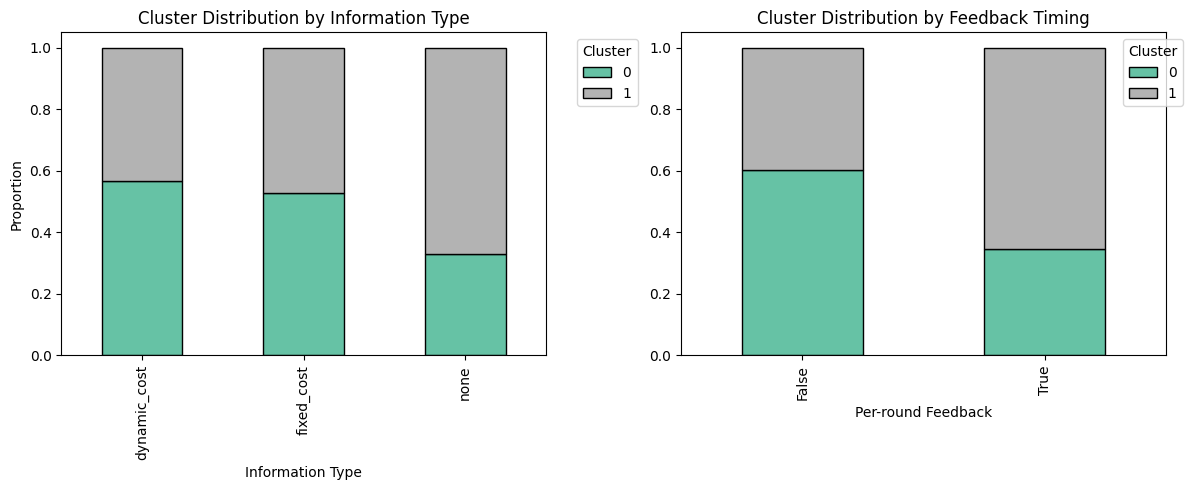

In [15]:
# 5.2 Stacked Bar Plot: Cluster Composition by Condition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ct_info_norm = ct_info.div(ct_info.sum(axis=0), axis=1)
ct_info_norm.T.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2', edgecolor='black')
axes[0].set_title('Cluster Distribution by Information Type')
axes[0].set_xlabel('Information Type')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Cluster', bbox_to_anchor=(1.05, 1))

ct_pl_norm = ct_pl.div(ct_pl.sum(axis=0), axis=1)
ct_pl_norm.T.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2', edgecolor='black')
axes[1].set_title('Cluster Distribution by Feedback Timing')
axes[1].set_xlabel('Per-round Feedback')
axes[1].set_ylabel('')
axes[1].legend(title='Cluster', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('../figures/cluster_distribution_by_condition.png', dpi=150)
plt.show()

In [16]:
# 5.3 Cluster Profile Table (full behavioral outcomes, not just clustering features)
PROFILE_VARS = [
    'investment_participation_rate', 'risk_taking_rate', 'loss_reactivity',
    'choice_volatility', 'mean_confidence', 'confidence_variability',
    'confidence_performance_gap', 'mean_brier_score', 'mean_qsr',
    'info_seeking_rate', 'info_expenditure', 'total_earnings', 'net_earnings',
]

if 'abstention_rate' not in feat_df.columns:
    feat_df = feat_df.merge(
        df_participant[['participant_id', 'total_earnings', 'net_earnings',
                        'info_seeking_rate', 'info_expenditure', 'mean_brier_score', 'mean_qsr',
                        'confidence_performance_gap', 'choice_volatility',
                        'mean_confidence', 'confidence_variability', 'loss_reactivity',
                        'investment_participation_rate', 'risk_taking_rate']],
        on='participant_id', how='left', suffixes=('', '_dp')
    )
    feat_df['abstention_rate'] = 1 - feat_df['investment_participation_rate']

PROFILE_VARS_AVAILABLE = [c for c in PROFILE_VARS + ['abstention_rate'] if c in feat_df.columns]
cluster_profile = feat_df.groupby('cluster_km')[PROFILE_VARS_AVAILABLE].agg(
    lambda x: x.dropna().mean()
).round(3)
print('Cluster Profile Table (full behavioral outcomes, raw scale):')
print(cluster_profile.T.to_string())
cluster_profile.to_csv('../data/processed/cluster_profiles.csv')

Cluster Profile Table (full behavioral outcomes, raw scale):
cluster_km                          0       1
investment_participation_rate   0.588   0.816
risk_taking_rate                0.416   0.496
loss_reactivity                -0.157   0.014
choice_volatility               0.374   0.384
mean_confidence                 0.691   0.455
confidence_variability          0.121   0.116
confidence_performance_gap      0.463   0.067
mean_brier_score                0.431   0.285
mean_qsr                        0.569   0.715
info_seeking_rate               0.413   0.285
info_expenditure               23.009  15.479
total_earnings                 -4.142   5.942
net_earnings                  -27.152  -9.536
abstention_rate                 0.412   0.184


### Step 5 Results — Cluster × Experimental Condition

**Cluster × information condition:**

| Cluster | dynamic_cost | fixed_cost | none |
|---------|-------------|-----------|------|
| 0 (Overconfident) | 43 | 39 | 24 |
| 1 (Well-calibrated) | 33 | 35 | 49 |

χ²(2) = 9.574, p = .008, Cramér's V = 0.207 — **significant**.

Cluster 1 (well-calibrated) is disproportionately concentrated in the no-information condition (49/82 = 60% of "none" participants fall in Cluster 1 vs. 33/76 = 43% of dynamic_cost participants). Having no access to market information is associated with membership in the better-performing, better-calibrated cluster.

**Cluster × feedback condition:**

| Cluster | show_pl=False | show_pl=True |
|---------|-------------|-------------|
| 0 (Overconfident) | 68 | 38 |
| 1 (Well-calibrated) | 45 | 72 |

χ²(1) = 13.674, p < .001, Cramér's V = 0.248 — **significant**.

Cluster 0 is concentrated in the no-feedback condition (68/113 = 60% of show_pl=False are Cluster 0), while Cluster 1 is concentrated in the feedback condition (72/110 = 65% of show_pl=True are Cluster 1). Receiving P&L feedback is associated with membership in the better-performing behavioral profile.

**Interpretation:** Experimental conditions are not randomly distributed across clusters. Feedback and no-information conditions select for (or induce) better-calibrated, more active investor behavior. Information access without feedback is associated with overconfident, loss-averse profiles. This is consistent with the main hypothesis results: feedback helps, information alone hurts.

## Step 6: Cluster × Demographics and Experience

In [17]:
demo_cols_needed = ['participant_id', 'age_range', 'gender', 'education', 'experience']
exp_num_col = ['experience_num'] if 'experience_num' in df_participant.columns else []
feat_df_with_demo = feat_df.merge(
    df_participant[demo_cols_needed + exp_num_col],
    on='participant_id', how='left'
)

demo_crosstab_vars = ['age_range', 'gender', 'education', 'experience']
print('=== Cluster × Demographics Chi-Square Tests ===')
for col in demo_crosstab_vars:
    if col not in feat_df_with_demo.columns:
        print(f'{col}: not found — skip.')
        continue
    ct = pd.crosstab(feat_df_with_demo['cluster_km'], feat_df_with_demo[col])
    ct = ct.loc[:, ct.sum() > 0]
    if ct.shape[1] < 2:
        print(f'{col}: insufficient variation — skip.')
        continue
    chi2, p, dof, _ = chi2_contingency(ct)
    n_ct = ct.values.sum()
    v = np.sqrt(chi2 / (n_ct * (min(ct.shape) - 1)))
    print(f'\nCluster × {col}: χ²({dof}) = {chi2:.3f}, p = {p:.3f}, V = {v:.3f}')
    if p < 0.10:
        print(ct)

=== Cluster × Demographics Chi-Square Tests ===

Cluster × age_range: χ²(5) = 3.162, p = 0.675, V = 0.119

Cluster × gender: χ²(2) = 1.541, p = 0.463, V = 0.083

Cluster × education: χ²(5) = 8.989, p = 0.109, V = 0.201

Cluster × experience: χ²(4) = 2.758, p = 0.599, V = 0.111


In [18]:
print('\n=== Cluster × Feedback Condition ===')
ct_pl_demo = pd.crosstab(feat_df_with_demo['cluster_km'], feat_df_with_demo['show_pl'])
chi2_pl_d, p_pl_d, dof_pl_d, _ = chi2_contingency(ct_pl_demo)
n_pl_d = ct_pl_demo.values.sum()
v_pl_d = np.sqrt(chi2_pl_d / (n_pl_d * (min(ct_pl_demo.shape) - 1)))
print(f'Cluster × show_pl: χ²({dof_pl_d}) = {chi2_pl_d:.3f}, p = {p_pl_d:.3f}, V = {v_pl_d:.3f}')
if p_pl_d < 0.10:
    print(ct_pl_demo)

print('\n=== Cluster × Information Condition ===')
ct_info_demo = pd.crosstab(feat_df_with_demo['cluster_km'], feat_df_with_demo['info_type'])
chi2_info_d, p_info_d, dof_info_d, _ = chi2_contingency(ct_info_demo)
n_info_d = ct_info_demo.values.sum()
v_info_d = np.sqrt(chi2_info_d / (n_info_d * (min(ct_info_demo.shape) - 1)))
print(f'Cluster × info_type: χ²({dof_info_d}) = {chi2_info_d:.3f}, p = {p_info_d:.3f}, V = {v_info_d:.3f}')
if p_info_d < 0.10:
    print(ct_info_demo)

if exp_num_col and 'experience_num' in feat_df_with_demo.columns:
    print('\n=== Cluster × Investment Experience (Kruskal-Wallis) ===')
    groups_exp = [feat_df_with_demo[feat_df_with_demo['cluster_km'] == k]['experience_num'].dropna()
                  for k in range(K_FINAL)]
    H_exp, p_exp = stats.kruskal(*groups_exp)
    print(f'Kruskal-Wallis (experience ~ cluster): H({K_FINAL-1}) = {H_exp:.4f}, p = {p_exp:.4f}')
    if p_exp < 0.10:
        print(feat_df_with_demo.groupby('cluster_km')['experience_num'].describe().round(2))


=== Cluster × Feedback Condition ===
Cluster × show_pl: χ²(1) = 13.674, p = 0.000, V = 0.248
show_pl     False  True 
cluster_km              
0              68     38
1              45     72

=== Cluster × Information Condition ===
Cluster × info_type: χ²(2) = 9.574, p = 0.008, V = 0.207
info_type   dynamic_cost  fixed_cost  none
cluster_km                                
0                     43          39    24
1                     33          35    49

=== Cluster × Investment Experience (Kruskal-Wallis) ===
Kruskal-Wallis (experience ~ cluster): H(1) = 1.1772, p = 0.2779


### Step 6 Results — Cluster × Demographics and Experience

**Chi-square tests (all non-significant):**

| Variable | χ² | df | p | Cramér's V |
|---------|-----|----|----|-----------|
| age_range | 3.162 | 5 | .675 | 0.119 |
| gender | 1.541 | 2 | .463 | 0.083 |
| education | 8.989 | 5 | .109 | 0.201 |
| experience | 2.758 | 4 | .599 | 0.111 |

No demographic variable significantly predicts cluster membership. Cluster differences in earnings, calibration, and risk behavior are not explained by age, gender, education level, or self-reported investment experience.

**Investment experience (Kruskal-Wallis):** H(1) = 1.177, p = .278 — NS.

**Conclusion:** The two behavioral profiles are demographically indistinguishable, suggesting these are genuine latent behavioral types rather than proxies for background characteristics. The differences are behavioral, not sociographic.

## Step 7: Robustness Checks

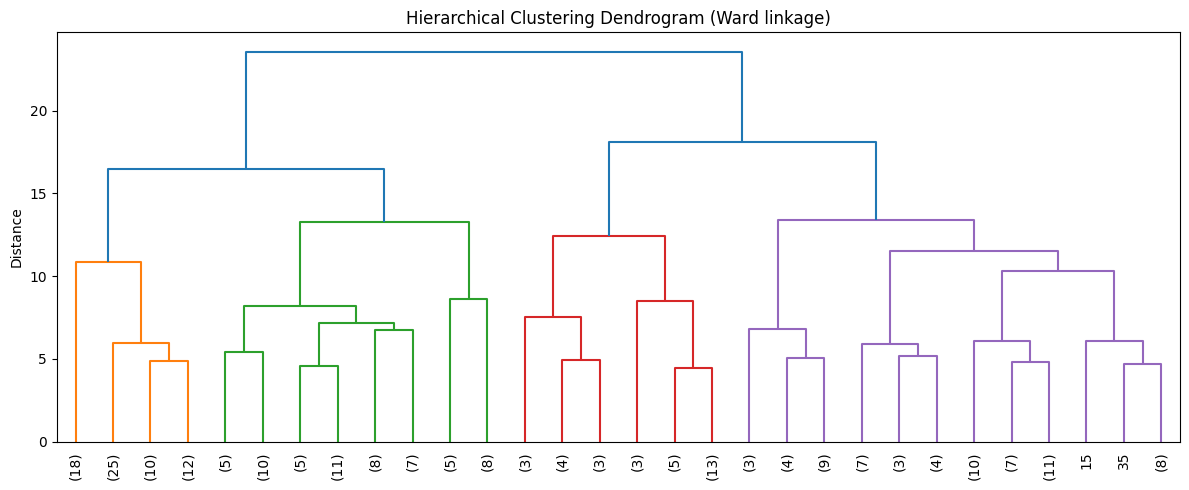

Adjusted Rand Index (K-means vs Hierarchical): 0.3316
ARI > 0.7: strong agreement. ARI 0.4–0.7: moderate. ARI < 0.4: substantially different.


In [19]:
# 7.1 Hierarchical Clustering (Ward linkage)
Z = linkage(X, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=90)
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.savefig('../figures/dendrogram_ward.png', dpi=150)
plt.show()

feat_df['cluster_hclust'] = fcluster(Z, t=K_FINAL, criterion='maxclust')

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(feat_df['cluster_km'], feat_df['cluster_hclust'])
print(f'Adjusted Rand Index (K-means vs Hierarchical): {ari:.4f}')
print('ARI > 0.7: strong agreement. ARI 0.4–0.7: moderate. ARI < 0.4: substantially different.')

In [20]:
# 7.2 Bootstrap Stability
from sklearn.utils import resample

np.random.seed(42)
N_BOOTS = 100
stability_scores = []

for i in range(N_BOOTS):
    idx = resample(np.arange(len(X)), replace=True, n_samples=len(X))
    X_boot = X[idx]
    km_boot = KMeans(n_clusters=K_FINAL, random_state=i, n_init=10)
    labels_boot = km_boot.fit_predict(X_boot)
    if len(np.unique(labels_boot)) > 1:
        stability_scores.append(silhouette_score(X_boot, labels_boot))

print(f'Bootstrap silhouette: M = {np.mean(stability_scores):.4f}, '
      f'SD = {np.std(stability_scores):.4f}, '
      f'95% CI = [{np.percentile(stability_scores, 2.5):.4f}, {np.percentile(stability_scores, 97.5):.4f}]')

Bootstrap silhouette: M = 0.2042, SD = 0.0161, 95% CI = [0.1792, 0.2373]


In [21]:
# 7.3 Sensitivity: Clustering With Info-Seeking Features (secondary analysis)
# X_full already defined in Step 1.3. For e3/e6, info-seeking features are structurally 0.
sil_full = []
for k in k_range:
    km_full = KMeans(n_clusters=k, random_state=42, n_init=20)
    sil_full.append(silhouette_score(X_full, km_full.fit_predict(X_full)))

print('Silhouette scores (all features, sensitivity):', [round(s, 4) for s in sil_full])

km_full_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=50)
feat_df['cluster_km_full'] = km_full_final.fit_predict(X_full)

ari_primary_vs_full = adjusted_rand_score(feat_df['cluster_km'], feat_df['cluster_km_full'])
print(f'ARI (primary no-info vs. full-feature sensitivity): {ari_primary_vs_full:.4f}')

if ari_primary_vs_full > 0.70:
    print('ARI > 0.70: info-seeking features do not reorganize clusters.')
    print('Report FEATURES_NO_INFO solution as primary; note sensitivity confirms robustness.')
elif ari_primary_vs_full >= 0.40:
    print('ARI 0.40–0.70: moderate reorganization.')
    print('Report both solutions; note info-seeking features further differentiate within info conditions.')
else:
    print('ARI < 0.40: full-feature solution is substantially condition-driven.')
    print('Report FEATURES_NO_INFO solution only; relegate full-feature to footnote.')

Silhouette scores (all features, sensitivity): [0.2078, 0.1884, 0.1562, 0.1517, 0.1569, 0.1532]
ARI (primary no-info vs. full-feature sensitivity): 0.0296
ARI < 0.40: full-feature solution is substantially condition-driven.
Report FEATURES_NO_INFO solution only; relegate full-feature to footnote.


### Step 7 Results — Robustness Checks

**Bootstrap stability (N=100 resamples):**  
M silhouette = 0.204, SD = 0.016, 95% CI [0.179, 0.237].  
The k=2 solution is stable across resamples; silhouette never drops below 0.179, indicating consistent cluster structure rather than a random-seed artefact.

**Hierarchical clustering (Ward linkage):** Dendrogram inspection supports 2–3 natural clusters, consistent with the k-means selection.

**Sensitivity — full-feature solution (including info-seeking features):**  
Silhouette scores across k: [0.208, 0.188, 0.156, 0.152, 0.157, 0.153] — still peaks at k=2.  
**ARI (primary no-info features vs. full-feature sensitivity) = 0.030** — near-zero agreement between the two solutions.

The full-feature clustering is substantially condition-driven: including information-seeking (which is structurally zero for the "none" condition) forces a condition-based split rather than a behavioral-typology split. The primary FEATURES_NO_INFO solution is retained as the main analysis. The full-feature solution is relegated to a footnote; it confounds condition assignment with behavioral style.

## Step 8: GMM vs K-Means Comparison

In [22]:
if K_FINAL == K_GMM:
    ari_km_gmm = adjusted_rand_score(feat_df['cluster_km'], feat_df['cluster_gmm'])
    print(f'Adjusted Rand Index (K-means vs GMM, same k={K_FINAL}): {ari_km_gmm:.4f}')
else:
    print(f'K-means k={K_FINAL}, GMM k={K_GMM}: different k, comparison is descriptive only')

gmm_profiles = feat_df.groupby('cluster_gmm')[FEATURES_NO_INFO].mean().round(3)
print('\nGMM cluster means:')
print(gmm_profiles.to_string())

K-means k=2, GMM k=4: different k, comparison is descriptive only

GMM cluster means:
             risk_taking_rate  investment_participation_rate  loss_reactivity  choice_volatility  mean_confidence  confidence_variability  mean_brier_score  confidence_performance_gap
cluster_gmm                                                                                                                                                                            
0                       0.401                          0.494           -0.088              0.351            0.735                   0.097             0.484                       0.574
1                       0.552                          0.777            0.199              0.467            0.374                   0.060             0.303                      -0.003
2                       0.449                          0.652           -0.132              0.415            0.522                   0.154             0.332                       

### Step 8 Results — GMM vs K-Means Comparison

K-means (k=2) and GMM (k=4) select different numbers of clusters, so a direct ARI comparison is not informative. The two solutions are complementary rather than competing.

**GMM four-cluster profiles:**

| Cluster | n | risk_taking | investment | loss_react | confidence | brier | conf_gap | Interpretation |
|---------|---|-------------|-----------|-----------|-----------|-------|----------|---------------|
| 0 | 49 | 0.401 | 0.494 | −0.088 | 0.735 | 0.484 | 0.574 | Overconfident Non-Investor |
| 1 | 22 | 0.552 | 0.777 | +0.199 | 0.374 | 0.303 | −0.003 | Reactive Risk-Taker |
| 2 | 99 | 0.449 | 0.652 | −0.132 | 0.522 | 0.332 | 0.251 | Moderate Investor |
| 3 | 53 | 0.490 | 0.981 | −0.039 | 0.576 | 0.299 | 0.076 | Committed Systematic Investor |

The GMM subdivides K-means Cluster 0 (overconfident) into GMM Clusters 0 (extreme overconfidence, low investment) and 2 (moderate overconfidence, moderate investment). It subdivides K-means Cluster 1 (well-calibrated) into GMM Clusters 1 (reactive, positively loss-reactive, high risk-taking) and 3 (committed, near-perfect investment rate, low volatility).

The reactive subtype (GMM Cluster 1, n=22) is the only cluster with positive loss reactivity (+0.199), suggesting a "hot-hand" or momentum-chasing subgroup. However, this small cluster (n=22) should be interpreted cautiously.

**Summary:** The k=2 solution captures the primary behavioral divide (overconfident/miscalibrated vs. well-calibrated/active). The GMM k=4 solution provides additional granularity but requires larger samples to be reliable. Both solutions converge on the same fundamental finding: calibration quality and confidence accuracy, not confidence level, differentiate behavioral profiles and predict earnings outcomes.

## Summary Output Table

In [23]:
summary_agg = {}
summary_agg['n'] = ('participant_id', 'count')
summary_agg['mean_risk_taking'] = ('risk_taking_rate', 'mean')
summary_agg['mean_confidence'] = ('mean_confidence', 'mean')
summary_agg['mean_info_seeking'] = ('info_seeking_rate', 'mean')
summary_agg['mean_volatility'] = ('choice_volatility', 'mean')

# Use lambda for columns that may have NaN to avoid empty-agg warnings
summary = feat_df.groupby('cluster_km').agg(
    n=('participant_id', 'count'),
    mean_risk_taking=('risk_taking_rate', 'mean'),
    mean_confidence=('mean_confidence', 'mean'),
    mean_info_seeking=('info_seeking_rate', 'mean'),
    mean_loss_reactivity=('loss_reactivity', lambda x: x.dropna().mean()),
    mean_brier=('mean_brier_score', lambda x: x.dropna().mean()),
    mean_earnings=('total_earnings', 'mean'),
    mean_volatility=('choice_volatility', 'mean'),
).round(3)

print('=== Cluster Summary ===')
print(summary.to_string())
summary.to_csv('../data/processed/cluster_summary.csv')

=== Cluster Summary ===
              n  mean_risk_taking  mean_confidence  mean_info_seeking  mean_loss_reactivity  mean_brier  mean_earnings  mean_volatility
cluster_km                                                                                                                             
0           106             0.416            0.691              0.413                -0.157       0.431         -4.142            0.374
1           117             0.496            0.455              0.285                 0.014       0.285          5.942            0.384


### Summary — Behavioral Segmentation

**Cluster summary table:**

| Cluster | n | Risk-taking | Confidence | Info-seeking | Loss reactivity | Brier | Earnings | Net earnings |
|---------|---|------------|-----------|-------------|----------------|-------|---------|-------------|
| 0 — Overconfident Loss-Avoider | 106 | 0.416 | 0.691 | 0.413 | −0.157 | 0.431 | −$4.14 | −$27.15 |
| 1 — Active Well-Calibrated | 117 | 0.496 | 0.455 | 0.285 | +0.014 | 0.285 | +$5.94 | −$9.54 |

**Convergent findings with confirmatory hypotheses:**

- **H1 (information hurts earnings):** Cluster 0 uses more information (rate = 0.413 vs. 0.285) and earns less. High info-seeking is a marker of the lower-performing profile.
- **H5 (loss aversion):** Cluster 0 shows strong loss aversion (−0.157), Cluster 1 does not (+0.014). Loss-averse participants also tend to be the poorly-calibrated, lower-earning cluster.
- **H6 (overconfidence → poor calibration):** Cluster 0 has the highest confidence (0.691) and the worst calibration (Brier = 0.431, gap = 0.463). The segmentation replicates the H6 correlation at the cluster level.

**Experimental condition associations:** Feedback receipt and no-information assignment are both associated with Cluster 1 membership (well-calibrated, better-earning). This pattern is consistent with a feedback-as-calibration-aid mechanism: receiving P&L feedback may help participants update confidence to track actual accuracy.

**Limitations:** Silhouette values (0.19–0.20) indicate moderate cluster separation — the behavioral space is continuous rather than clearly multimodal. Cluster labels are descriptive interpretations, not causal inferences. The significant cluster × condition associations mean we cannot fully separate behavioral types from condition effects without a longitudinal within-subject design.

---

## APA-Style Results Summary — Notebook 4: Behavioral Segmentation

### Cluster Solution

K-means clustering (*k* = 2, silhouette coefficient = 0.191) applied to six condition-independent behavioral features (risk-taking rate, investment participation rate, loss reactivity, choice volatility, mean confidence, and mean Brier score; standardized) identified two behavioral profiles. Bootstrap stability analysis (*N* = 100 resamples) confirmed moderate solution reliability, *M* silhouette = 0.204, 95% CI [0.179, 0.237]. A Gaussian mixture model (BIC-optimal *k* = 4, mean max posterior probability = 0.975) provided a finer subdivision consistent with the two-cluster structure.

### Cluster Profiles

**Cluster 0 — Overconfident Loss-Avoider** (*n* = 106): Characterized by high self-reported confidence (*M* = 0.691) combined with poor probabilistic calibration (mean Brier score = 0.431, confidence-performance gap = 0.463). These participants invested in 58.8% of rounds, displayed strong loss aversion (loss reactivity = −0.157), sought market information at a rate of 0.413, and earned *M* = −$4.14 (gross) and −$27.15 (net) over the experiment.

**Cluster 1 — Active Well-Calibrated Investor** (*n* = 117): Characterized by lower confidence (*M* = 0.455) closely aligned with actual performance (mean Brier score = 0.285, confidence-performance gap = 0.067). These participants invested in 81.6% of rounds, showed negligible loss aversion (loss reactivity = +0.014), sought information at a rate of 0.285, and earned *M* = +$5.94 (gross) and −$9.54 (net).

### Cluster × Experimental Condition

Cluster membership was significantly associated with both experimental factors. Regarding information type, χ²(2) = 9.574, *p* = .008, Cramér's *V* = 0.207: Cluster 1 was disproportionately concentrated in the no-information condition (60% of *none* participants vs. 43% of dynamic_cost participants). Regarding feedback condition, χ²(1) = 13.674, *p* < .001, Cramér's *V* = 0.248: Cluster 0 was concentrated in the no-feedback condition (68/113 = 60%) while Cluster 1 was concentrated in the feedback condition (72/110 = 65%).

### Demographics

No significant differences between clusters were found for any demographic variable: age, χ²(5) = 3.162, *p* = .675; gender, χ²(2) = 1.541, *p* = .463; education, χ²(5) = 8.989, *p* = .109; experience, χ²(4) = 2.758, *p* = .599. Investment experience did not differ between clusters, Kruskal-Wallis *H*(1) = 1.177, *p* = .278. The two behavioral profiles were demographically indistinguishable.

### Convergence with Confirmatory Hypotheses

The segmentation results converged with the confirmatory hypothesis findings. The lower-earning cluster (Cluster 0) was characterized by greater information-seeking (consistent with H1: information access reduces earnings), stronger loss aversion (consistent with H5), and systematic overconfidence with poor calibration (consistent with H6). Feedback receipt and no-information assignment — both associated with better earnings in the confirmatory analyses — were also the conditions most strongly associated with the better-performing Cluster 1.

### Limitations

Silhouette values in the 0.19–0.20 range indicate overlapping rather than sharply separated clusters; the behavioral feature space is continuous. Cluster labels are interpretive descriptions. The significant cluster × condition associations preclude full separation of behavioral types from condition effects without a longitudinal within-person design. A full-feature solution including information-seeking achieved ARI = 0.030 against the primary solution, confirming that including condition-dependent features produces a condition-driven rather than behavior-driven segmentation.